# Citi Bike + Weather Merge Notebook

This notebook rebuilds the station-hour training table from raw Citi Bike trip CSVs without loading the full trip history or a full multi-year station x hour grid into memory.

Processing flow:
1. Stream raw trip CSVs in chunks and apply the trip-data cleaning rules documented in `docs/CitiBike_Final_Report.docx.md`.
2. Aggregate monthly station-hour inflow and outflow CSVs, plus compact trip-data EDA summary tables.
3. Rebuild the zero-filled feature table month by month with 24-hour lag carryover, merge hourly weather, and append the final dataset to CSV incrementally.
4. Validate the final output, show a final training-set sample, and compute the trip-feature correlation heatmap in a memory-safe way.

Set `RESET_OUTPUTS = True` before rerunning the full build if notebook-generated CSV outputs already exist and you want to overwrite them.


In [21]:
from pathlib import Path

import importlib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import merge_trip_weather_v1_0_support as support
importlib.reload(support)

TRIP_CORR_COLS = support.TRIP_CORR_COLS
build_final_dataset = support.build_final_dataset
build_paths = support.build_paths
compute_chunked_correlation = support.compute_chunked_correlation
load_eda_outputs = support.load_eda_outputs
load_weather_df = support.load_weather_df
prepare_output_area = support.prepare_output_area
run_streamed_trip_aggregation = support.run_streamed_trip_aggregation
validate_final_output = support.validate_final_output

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

PROJECT_ROOT = Path.cwd()
TARGET_YEARS = {2023}
CHUNK_SIZE = 250_000
AGG_FLUSH_THRESHOLD = 600_000
STATION_BATCH_SIZE = 64
RESET_OUTPUTS = False

paths = build_paths(PROJECT_ROOT, TARGET_YEARS)
paths


MergePaths(project_root=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction'), trip_root=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/citibike'), weather_path=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/weather/open-meteo-2023-2025.csv'), output_dir=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/proceed'), work_dir=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/merge_trip_weather_v1_0_work'), monthly_agg_dir=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/merge_trip_weather_v1_0_work/monthly_station_hour'), eda_dir=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/merge_trip_weather_v1_0_work/eda'), output_path=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2023_2023_weather.csv'), coords_path=WindowsPath('d:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/merge_trip_weather_

In [9]:
prepare_output_area(paths, reset_outputs=RESET_OUTPUTS)

trip_report = run_streamed_trip_aggregation(
    paths,
    TARGET_YEARS,
    chunk_size=CHUNK_SIZE,
    agg_flush_threshold=AGG_FLUSH_THRESHOLD,
)

print(f"Trip files processed: {len(trip_report['trip_files'])}")
print(
    'Trip date range:',
    trip_report['global_date_min'],
    'to',
    trip_report['global_date_max'],
)
display(trip_report['cleaning_summary'])
display(trip_report['monthly_summary'])


FileExistsError: Notebook-generated outputs already exist. Set RESET_OUTPUTS = True to overwrite them.
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\coords_lookup.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\eda\cleaning_summary.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\eda\hourly_member_casual.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\eda\hourly_weekday_weekend.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\eda\top_start_stations.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\monthly_processing_summary.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weather_v1_0_work\eda\feature_correlation.csv
d:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\merge_trip_weathe

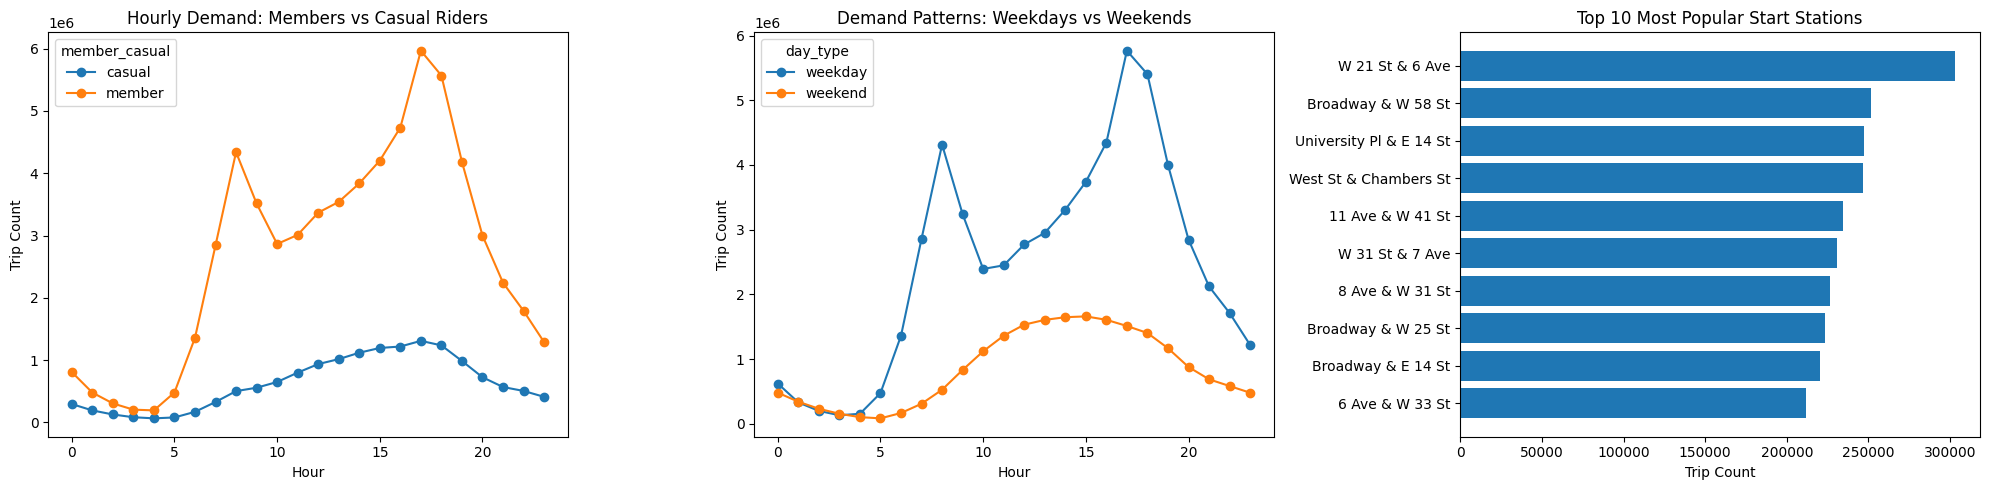

,metric,value
0,trip_file_count,90
1,month_count,24
2,raw_rows,79410195
3,invalid_timestamp_rows,0
4,duration_under_1min_rows,825
5,duration_over_1440min_rows,37576
6,missing_end_station_rows,186104
7,missing_start_station_rows,20266
8,clean_rows,79165424
9,station_count,2401


,station,trip_count
0,W 21 St & 6 Ave,302999
1,Broadway & W 58 St,251440
2,University Pl & E 14 St,247017
3,West St & Chambers St,246355
4,11 Ave & W 41 St,234353
5,W 31 St & 7 Ave,230540
6,8 Ave & W 31 St,226560
7,Broadway & W 25 St,223377
8,Broadway & E 14 St,220069
9,6 Ave & W 33 St,211877


In [10]:
eda = load_eda_outputs(paths)

member_pivot = (
    eda['member_hourly']
    .pivot(index='hour', columns='member_casual', values='trip_count')
    .fillna(0)
    .sort_index()
)
daytype_pivot = (
    eda['daytype_hourly']
    .pivot(index='hour', columns='day_type', values='trip_count')
    .fillna(0)
    .sort_index()
)
top_start_10 = eda['top_start'].head(10).sort_values('trip_count')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
member_pivot.plot(ax=axes[0], marker='o')
axes[0].set_title('Hourly Demand: Members vs Casual Riders')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Trip Count')

daytype_pivot.plot(ax=axes[1], marker='o')
axes[1].set_title('Demand Patterns: Weekdays vs Weekends')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Trip Count')

axes[2].barh(top_start_10['station'], top_start_10['trip_count'])
axes[2].set_title('Top 10 Most Popular Start Stations')
axes[2].set_xlabel('Trip Count')

plt.tight_layout()
plt.show()

display(eda['cleaning_summary'])
display(eda['top_start'].head(10))


In [11]:
coords_lookup = pd.read_csv(paths.coords_path)
weather_df = load_weather_df(paths.weather_path)

print('Station count:', len(coords_lookup))
print('Weather rows:', len(weather_df))
print('Weather range:', weather_df['datetime_hour'].min(), 'to', weather_df['datetime_hour'].max())
display(coords_lookup.head())
display(weather_df.head())


Station count: 2401
Weather rows: 26304
Weather range: 2023-01-01 00:00:00 to 2025-12-31 23:00:00


,station,lat,lng,coord_count
0,1 Ave & E 110 St,40.792327,-73.938300,97620
1,1 Ave & E 118 St,40.797459,-73.934499,23738
2,1 Ave & E 16 St,40.732219,-73.981656,262549
3,1 Ave & E 18 St,40.733812,-73.980544,294005
4,1 Ave & E 30 St,40.741444,-73.975361,211679


,datetime_hour,temp_2m,rh_2m,rain_mm,snow_cm,wind_kmh,precip_mm,cloud_cover,cloud_low,cloud_mid,cloud_high
0,2023-01-01 00:00:00,-19.4,81,0.0,0.0,5.4,0.0,0,0,0,0
1,2023-01-01 01:00:00,-16.1,69,0.0,0.0,4.8,0.0,0,0,0,0
2,2023-01-01 02:00:00,-14.2,62,0.0,0.0,3.8,0.0,0,0,0,0
3,2023-01-01 03:00:00,-13.2,60,0.0,0.0,3.2,0.0,0,0,0,0
4,2023-01-01 04:00:00,-13.1,60,0.0,0.0,3.8,0.0,0,0,0,0


In [12]:
final_report = build_final_dataset(paths, station_batch_size=STATION_BATCH_SIZE)

print(f"Stations written: {final_report['station_count']}")
print(f"Months written: {final_report['month_count']}")
print(f"Final rows written: {final_report['rows_written']:,}")
display(final_report['month_write_summary'])


Wrote 1,786,344 rows for month 202301
Wrote 1,613,472 rows for month 202302
Wrote 1,786,344 rows for month 202303
Wrote 1,728,720 rows for month 202304
Wrote 1,786,344 rows for month 202305
Wrote 1,728,720 rows for month 202306
Wrote 1,786,344 rows for month 202307
Wrote 1,786,344 rows for month 202308
Wrote 1,728,720 rows for month 202309
Wrote 1,786,344 rows for month 202310
Wrote 1,728,720 rows for month 202311
Wrote 1,786,344 rows for month 202312
Wrote 1,786,344 rows for month 202401
Wrote 1,671,096 rows for month 202402
Wrote 1,786,344 rows for month 202403
Wrote 1,728,720 rows for month 202404
Wrote 1,786,344 rows for month 202405
Wrote 1,728,720 rows for month 202406
Wrote 1,786,344 rows for month 202407
Wrote 1,786,344 rows for month 202408
Wrote 1,728,720 rows for month 202409
Wrote 1,786,344 rows for month 202410
Wrote 1,728,720 rows for month 202411
Wrote 1,786,344 rows for month 202412
Stations written: 2401
Months written: 24
Final rows written: 42,123,144


,month_key,hour_count,rows_written
0,202301,744,1786344
1,202302,672,1613472
2,202303,744,1786344
3,202304,720,1728720
4,202305,744,1786344
5,202306,720,1728720
6,202307,744,1786344
7,202308,744,1786344
8,202309,720,1728720
9,202310,744,1786344


In [13]:
validation = validate_final_output(paths)
validation_df = pd.DataFrame(
    [
        {'metric': 'expected_rows', 'value': validation['expected_rows']},
        {'metric': 'actual_rows', 'value': validation['actual_rows']},
        {'metric': 'rows_match_expected', 'value': validation['rows_match_expected']},
        {'metric': 'station_count', 'value': validation['station_count']},
    ]
)
weather_null_df = pd.DataFrame(
    [
        {'weather_feature': key, 'null_pct': value}
        for key, value in validation['weather_null_pct'].items()
    ]
)

display(validation_df)
display(weather_null_df)

if not validation['rows_match_expected']:
    raise ValueError(
        'Final CSV row count does not match the expected station-hour grid. '
        'Rerun from the build cell with RESET_OUTPUTS = True.'
    )


,metric,value
0,expected_rows,42123144
1,actual_rows,42123144
2,rows_match_expected,True
3,station_count,2401


,weather_feature,null_pct
0,temp_2m,0.0
1,rh_2m,0.0
2,precip_mm,0.0
3,snow_cm,0.0
4,wind_kmh,0.0
5,cloud_cover,0.0


In [16]:
final_head = pd.read_csv(paths.output_path, nrows=10)
tail_chunk = None
for tail_chunk in pd.read_csv(paths.output_path, chunksize=200_000):
    pass

print('Final training-set head sample (all columns):')
display(final_head)

print('Final training-set tail sample (all columns):')
display(tail_chunk.tail(10))


Final training-set head sample (all columns):


,station,date,hour,datetime_hour,is_weekend,net_demand,lat,lng,hour_sin,hour_cos,day_of_week,day_sin,day_cos,lag_1h,lag_2h,lag_3h,lag_24h,rolling_mean_3h,temp_2m,rh_2m,rain_mm,snow_cm,wind_kmh,precip_mm,cloud_cover,cloud_low,cloud_mid,cloud_high,is_raining,is_snowing
0,1 Ave & E 110 St,2023-01-01,0,2023-01-01 00:00:00,1,0.0,40.792328,-73.9383,0.000000,1.000000e+00,6,-0.781832,0.62349,0.0,0.0,0.0,0.0,0.000000,-19.4,81,0.0,0.0,5.4,0.0,0,0,0,0,0,0
1,1 Ave & E 110 St,2023-01-01,1,2023-01-01 01:00:00,1,-1.0,40.792328,-73.9383,0.258819,9.659258e-01,6,-0.781832,0.62349,0.0,0.0,0.0,0.0,0.000000,-16.1,69,0.0,0.0,4.8,0.0,0,0,0,0,0,0
2,1 Ave & E 110 St,2023-01-01,2,2023-01-01 02:00:00,1,2.0,40.792328,-73.9383,0.500000,8.660254e-01,6,-0.781832,0.62349,-1.0,0.0,0.0,0.0,-0.333333,-14.2,62,0.0,0.0,3.8,0.0,0,0,0,0,0,0
3,1 Ave & E 110 St,2023-01-01,3,2023-01-01 03:00:00,1,0.0,40.792328,-73.9383,0.707107,7.071068e-01,6,-0.781832,0.62349,2.0,-1.0,0.0,0.0,0.333333,-13.2,60,0.0,0.0,3.2,0.0,0,0,0,0,0,0
4,1 Ave & E 110 St,2023-01-01,4,2023-01-01 04:00:00,1,0.0,40.792328,-73.9383,0.866025,5.000000e-01,6,-0.781832,0.62349,0.0,2.0,-1.0,0.0,0.333333,-13.1,60,0.0,0.0,3.8,0.0,0,0,0,0,0,0
5,1 Ave & E 110 St,2023-01-01,5,2023-01-01 05:00:00,1,-2.0,40.792328,-73.9383,0.965926,2.588190e-01,6,-0.781832,0.62349,0.0,0.0,2.0,0.0,0.666667,-11.7,40,0.0,0.0,3.3,0.0,0,0,0,0,0,0
6,1 Ave & E 110 St,2023-01-01,6,2023-01-01 06:00:00,1,-1.0,40.792328,-73.9383,1.000000,6.123234e-17,6,-0.781832,0.62349,-2.0,0.0,0.0,0.0,-0.666667,-11.7,38,0.0,0.0,2.6,0.0,0,0,0,0,0,0
7,1 Ave & E 110 St,2023-01-01,7,2023-01-01 07:00:00,1,1.0,40.792328,-73.9383,0.965926,-2.588190e-01,6,-0.781832,0.62349,-1.0,-2.0,0.0,0.0,-1.000000,-12.4,42,0.0,0.0,3.6,0.0,0,0,0,0,0,0
8,1 Ave & E 110 St,2023-01-01,8,2023-01-01 08:00:00,1,0.0,40.792328,-73.9383,0.866025,-5.000000e-01,6,-0.781832,0.62349,1.0,-1.0,-2.0,0.0,-0.666667,-13.2,43,0.0,0.0,5.2,0.0,0,0,0,0,0,0
9,1 Ave & E 110 St,2023-01-01,9,2023-01-01 09:00:00,1,-1.0,40.792328,-73.9383,0.707107,-7.071068e-01,6,-0.781832,0.62349,0.0,1.0,-1.0,0.0,0.000000,-13.8,44,0.0,0.0,5.5,0.0,0,0,0,0,0,0


Final training-set tail sample (all columns):


,station,date,hour,datetime_hour,is_weekend,net_demand,lat,lng,hour_sin,hour_cos,day_of_week,day_sin,day_cos,lag_1h,lag_2h,lag_3h,lag_24h,rolling_mean_3h,temp_2m,rh_2m,rain_mm,snow_cm,wind_kmh,precip_mm,cloud_cover,cloud_low,cloud_mid,cloud_high,is_raining,is_snowing
42123134,York St & Marin Blvd,2024-12-31,14,2024-12-31 14:00:00,0,0.0,40.716614,-74.04241,-0.500000,-8.660254e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-14.9,91,0.0,0.00,1.1,0.0,90,69,84,0,0,0
42123135,York St & Marin Blvd,2024-12-31,15,2024-12-31 15:00:00,0,0.0,40.716614,-74.04241,-0.707107,-7.071068e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-15.3,88,0.0,0.00,1.7,0.0,55,18,53,9,0,0
42123136,York St & Marin Blvd,2024-12-31,16,2024-12-31 16:00:00,0,0.0,40.716614,-74.04241,-0.866025,-5.000000e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-16.5,89,0.0,0.00,1.5,0.0,79,7,79,0,0,0
42123137,York St & Marin Blvd,2024-12-31,17,2024-12-31 17:00:00,0,0.0,40.716614,-74.04241,-0.965926,-2.588190e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-17.8,93,0.0,0.00,1.7,0.0,100,6,100,100,0,0
42123138,York St & Marin Blvd,2024-12-31,18,2024-12-31 18:00:00,0,0.0,40.716614,-74.04241,-1.000000,-1.836970e-16,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-19.5,94,0.0,0.00,1.7,0.0,100,59,100,98,0,0
42123139,York St & Marin Blvd,2024-12-31,19,2024-12-31 19:00:00,0,0.0,40.716614,-74.04241,-0.965926,2.588190e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-20.0,89,0.0,0.00,0.7,0.0,100,62,100,100,0,0
42123140,York St & Marin Blvd,2024-12-31,20,2024-12-31 20:00:00,0,0.0,40.716614,-74.04241,-0.866025,5.000000e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-19.0,82,0.0,0.07,1.5,0.1,100,66,100,96,1,1
42123141,York St & Marin Blvd,2024-12-31,21,2024-12-31 21:00:00,0,0.0,40.716614,-74.04241,-0.707107,7.071068e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-17.2,83,0.0,0.21,1.5,0.3,100,80,100,46,1,1
42123142,York St & Marin Blvd,2024-12-31,22,2024-12-31 22:00:00,0,0.0,40.716614,-74.04241,-0.500000,8.660254e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-16.8,82,0.0,0.21,2.9,0.3,100,78,100,99,1,1
42123143,York St & Marin Blvd,2024-12-31,23,2024-12-31 23:00:00,0,0.0,40.716614,-74.04241,-0.258819,9.659258e-01,1,0.781832,0.62349,0.0,0.0,0.0,0.0,0.0,-16.6,81,0.0,0.14,2.9,0.2,100,54,100,100,1,1


In [20]:
import importlib

import merge_trip_weather_v1_0_support as support

importlib.reload(support)
corr_cols = support.TRIP_CORR_COLS
print(f'TRIP_CORR_COLS ({len(corr_cols)}):')
print(corr_cols)

['net_demand', 'hour', 'is_weekend', 'day_of_week', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h']


Computed correlation matrix with 27 columns
['net_demand', 'lat', 'lng', 'hour', 'is_weekend', 'day_of_week', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h', 'temp_2m', 'rh_2m', 'rain_mm', 'snow_cm', 'wind_kmh', 'precip_mm', 'cloud_cover', 'cloud_low', 'cloud_mid', 'cloud_high', 'is_raining', 'is_snowing']


net_demand         1.000000e+00
rh_2m              4.008896e-01
cloud_low          6.771824e-02
lng                1.306987e-02
lag_24h            1.305948e-02
cloud_cover        1.282393e-02
lag_1h             8.206311e-03
snow_cm            7.832104e-03
rolling_mean_3h    5.992871e-03
lag_2h             4.459967e-03
day_cos            2.791692e-16
lat                0.000000e+00
hour_cos           0.000000e+00
day_sin           -3.293431e-16
hour              -1.970201e-14
is_weekend        -5.440200e-14
lag_3h            -5.531833e-04
is_snowing        -9.285576e-03
cloud_mid         -1.065552e-02
precip_mm         -3.669286e-02
cloud_high        -4.803701e-02
rain_mm           -6.379579e-02
hour_sin          -1.021508e-01
is_raining        -1.266788e-01
wind_kmh          -1.305780e-01
temp_2m           -3.317237e-01
day_of_week       -7.759122e-01
Name: net_demand, dtype: float64

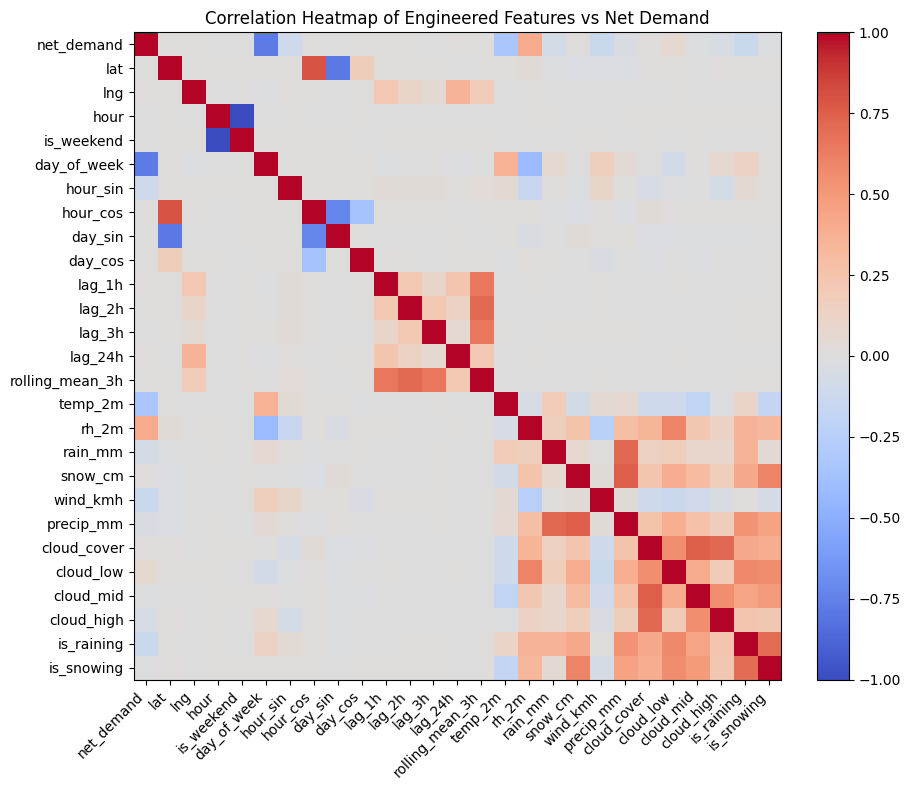

In [23]:
import importlib

import merge_trip_weather_v1_0_support as support

importlib.reload(support)
corr_cols = support.TRIP_CORR_COLS
corr_fn = support.compute_chunked_correlation

corr_df = corr_fn(paths.output_path, corr_cols)
corr_df.to_csv(paths.correlation_path)
print(f'Computed correlation matrix with {corr_df.shape[0]} columns')
print(corr_df.columns.tolist())

display(corr_df['net_demand'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_df.index)
ax.set_title('Correlation Heatmap of Engineered Features vs Net Demand')
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
